# **Customer Claim Prediction for Travel Insurance: Improving Risk Control**

In [1]:
# Import library

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from category_encoders import BinaryEncoder

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectPercentile, f_classif
from sklearn.metrics import recall_score, precision_score, make_scorer, average_precision_score, fbeta_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_validate, StratifiedKFold, RandomizedSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Import dataset
df = pd.read_csv('data_travel_insurance.csv')
df.head()

,Agency,Agency Type,Distribution Channel,Product Name,Gender,Duration,Destination,Net Sales,Commision (in value),Age,Claim
0,C2B,Airlines,Online,Annual Silver Plan,F,365,SINGAPORE,216.0,54.0,57,No
1,EPX,Travel Agency,Online,Cancellation Plan,NaN,4,MALAYSIA,10.0,0.0,33,No
2,JZI,Airlines,Online,Basic Plan,M,19,INDIA,22.0,7.7,26,No
3,EPX,Travel Agency,Online,2 way Comprehensive Plan,NaN,20,UNITED STATES,112.0,0.0,59,No
4,C2B,Airlines,Online,Bronze Plan,M,8,SINGAPORE,16.0,4.0,28,No


# **Section 1. Business Understanding**

## 1.1 Context

The travel insurance industry provides protection for customers during both domestic and international trips. Insurance products vary depending on factors such as travel duration, destination, and the level of coverage selected. One of the key challenges in this industry is the uncertainty of insurance claims. A high number of claims can significantly increase operational costs and reduce company profitability.

By leveraging historical customer data, the company aims to identify patterns that can help predict whether a policyholder is likely to submit an insurance claim. Currently, the risk management teams do not have a reliable system to identify customers who are likely to submit an insurance claim. As a result, financial risk increases due to unpredictable claim behavior.

The objective of this project is to build a machine learning model that predicts whether a customer will submit an insurance claim (classification problem) and supports the business in reducing financial risk from claims.

## 1.2 Stakeholders

The primary stakeholders of this project include the Risk Management Team, the Marketing Team, and Management or Investors. However, the main focus of this project is the Risk Management Team, as the core objective is to predict and mitigate insurance claim risk.

The Risk Management Team will leverage the model to identify high-risk policyholders before or during policy issuance. This enables them to make more informed decisions regarding pricing strategies, policy approvals, and risk mitigation actions. Since insurance claims directly impact the company’s financial exposure, accurately identifying potential claims is critical to reducing unexpected losses.

In this context, the cost of misclassification is not equal. Failing to identify a high-risk customer (false negative) can result in significant financial loss, as the company may underprice or improperly accept a risky policy. Therefore, the model is designed to prioritize recall for claim cases, ensuring that as many high-risk customers as possible are detected.

While the Marketing Team may use the model to improve campaign efficiency, and Management focuses on overall profitability, these benefits are secondary. The primary value of this model lies in its ability to support the Risk Management Team in reducing claim-related losses and improving financial stability.

## 1.3 Analytical Approach

This project uses a supervised learning and classification approach, since the target variable (Claim) is categorical (Yes/No).

The model will learn patterns from features such as:
- Travel duration
- Destination
- Product type
- Customer demographics
- Financial variables

## 1.4 Main Evaluation Metric

Since the primary business objective is to reduce financial risk from claims, the model must be able to correctly identify as many claim cases as possible. Therefore, the main evaluation metric is Recall (for the “Claim = Yes” class). We want a model that provides the least False Negatives (FN), or customers who actually submit claims but are predicted as non-claim. This is critical because the company is unprepared for the claim and potential financial losses increase.

Given the dataset is possibly imbalanced, additional metric of PR AUC, precision, and F2-score are also evaluated to ensure the model does not excessively predict claims, which could reduce operational efficiency.

## 1.5 Five Points Business ML Formulation

| Component    | Description                                                 |
| ------------ | ----------------------------------------------------------- |
| Problem      | Inability to identify customers likely to submit claims     |
| Data         | Historical travel insurance customer data                   |
| ML Objective | Predict claim likelihood (classification)                   |
| Action       | Use predictions for risk control                            |
| Value        | Reduce claim-related costs                                  |

# **Section 2. Data Understanding**

## 2.1 General Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44328 entries, 0 to 44327
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Agency                44328 non-null  object 
 1   Agency Type           44328 non-null  object 
 2   Distribution Channel  44328 non-null  object 
 3   Product Name          44328 non-null  object 
 4   Gender                12681 non-null  object 
 5   Duration              44328 non-null  int64  
 6   Destination           44328 non-null  object 
 7   Net Sales             44328 non-null  float64
 8   Commision (in value)  44328 non-null  float64
 9   Age                   44328 non-null  int64  
 10  Claim                 44328 non-null  object 
dtypes: float64(2), int64(2), object(7)
memory usage: 3.7+ MB


All data types are correct.

## 2.2 Feature Information

| Feature Name         | Description                                     | Impact to Business                                                                    |
| -------------------- | ----------------------------------------------- | ------------------------------------------------------------------------------------- |
| Agency               | Name of agency                                  | Helps evaluate performance and risk patterns across different agencies                |
| Agency Type          | Type of travel insurance agencies               | Indicates differences in business models that may influence claim behavior            |
| Distribution Channel | Channel of travel insurance agencies            | Useful for analyzing which channels produce higher-risk customers or claims           |
| Product Name         | Name of the travel insurance products           | Different products may have different coverage levels and claim probabilities         |
| Gender               | Gender of insured                               | Enables demographic-based risk analysis and segmentation                              |
| Duration             | Duration of travel                              | Longer trips may increase exposure to risk and likelihood of claims                   |
| Destination          | Destination of travel                           | Certain destinations may carry higher risk (e.g., healthcare cost, safety issues)     |
| Net Sales            | Amount of sales of travel insurance policies    | Reflects customer value and potential exposure to financial risk                      |
| Commission           | Commission received for travel insurance agency | Indicates agency incentives that may influence sales behavior and risk quality        |
| Age                  | Age of insured                                  | Strong indicator of risk profile; certain age groups may have higher claim likelihood |
| Claim                | Claim status (Yes/No)                           | Target variable used to predict and reduce claim-related financial losses             |


## 2.3 Statistics Summary

In [4]:
print("Numerical Summary: ")
display(df.describe())
print("Categorical Summary: ")
display(df.describe(include='object'))

Numerical Summary: 


,Duration,Net Sales,Commision (in value),Age
count,44328.000000,44328.000000,44328.000000,44328.000000
mean,49.424292,40.550948,9.707692,39.925600
std,109.153961,48.661970,19.625637,13.954926
min,-1.000000,-357.500000,0.000000,0.000000
25%,9.000000,18.000000,0.000000,35.000000
50%,22.000000,26.500000,0.000000,36.000000
75%,53.000000,48.000000,11.550000,43.000000
max,4881.000000,810.000000,283.500000,118.000000


Categorical Summary: 


,Agency,Agency Type,Distribution Channel,Product Name,Gender,Destination,Claim
count,44328,44328,44328,44328,12681,44328,44328
unique,16,2,2,26,2,138,2
top,EPX,Travel Agency,Online,Cancellation Plan,M,SINGAPORE,No
freq,24656,32113,43572,12979,6504,9267,43651


# **Section 3. Data Cleaning**

Data cleaning is critical to ensure our data is clean and ready to be processed. Any decision based on uncleaned data is questionable.

## 3.1 Initial Observations

In [5]:
pd.set_option('display.max_colwidth', None)

# unique data on each column
listItem = []

for col in df.columns :
    listItem.append( [col, df[col].nunique(), df[col].unique()])

tableDesc = pd.DataFrame(columns=['Column Name', 'Number of Unique', 'Unique Values'], data=listItem)
tableDesc

,Column Name,Number of Unique,Unique Values
0,Agency,16,"[C2B, EPX, JZI, CWT, LWC, ART, CSR, SSI, RAB, KML, TST, TTW, JWT, ADM, CCR, CBH]"
1,Agency Type,2,"[Airlines, Travel Agency]"
2,Distribution Channel,2,"[Online, Offline]"
3,Product Name,26,"[Annual Silver Plan, Cancellation Plan, Basic Plan, 2 way Comprehensive Plan, Bronze Plan, 1 way Comprehensive Plan, Rental Vehicle Excess Insurance, Single Trip Travel Protect Gold, Silver Plan, Value Plan, 24 Protect, Annual Travel Protect Gold, Comprehensive Plan, Ticket Protector, Travel Cruise Protect, Single Trip Travel Protect Silver, Individual Comprehensive Plan, Gold Plan, Annual Gold Plan, Child Comprehensive Plan, Premier Plan, Annual Travel Protect Silver, Single Trip Travel Protect Platinum, Annual Travel Protect Platinum, Spouse or Parents Comprehensive Plan, Travel Cruise Protect Family]"
4,Gender,2,"[F, nan, M]"
5,Duration,437,"[365, 4, 19, 20, 8, 2, 25, 90, 24, 43, 103, 376, 6, 16, 27, 34, 3, 14, 12, 31, 5, 7, 56, 29, 30, 58, 9, 38, 42, 11, 13, 40, 79, 370, 366, 26, 83, 55, 18, 100, 1, 35, 36, 75, 23, 73, 32, 232, 37, 10, 4736, 15, 17, 99, 173, 74, 82, 66, 156, 39, 95, 98, 111, 430, 53, 77, 87, 70, 151, 45, 54, 114, 118, 62, 28, 112, 326, 22, 59, 44, 21, 97, 63, 60, 51, 180, 160, 368, 65, 93, 71, 57, 0, 76, 69, 110, 146, 116, 129, 84, ...]"
6,Destination,138,"[SINGAPORE, MALAYSIA, INDIA, UNITED STATES, KOREA, REPUBLIC OF, THAILAND, GERMANY, JAPAN, INDONESIA, VIET NAM, AUSTRALIA, FINLAND, UNITED KINGDOM, SRI LANKA, SPAIN, HONG KONG, MACAO, CHINA, UNITED ARAB EMIRATES, IRAN, ISLAMIC REPUBLIC OF, TAIWAN, PROVINCE OF CHINA, POLAND, CANADA, OMAN, PHILIPPINES, GREECE, BELGIUM, TURKEY, BRUNEI DARUSSALAM, DENMARK, SWITZERLAND, NETHERLANDS, SWEDEN, MYANMAR, KENYA, CZECH REPUBLIC, FRANCE, RUSSIAN FEDERATION, PAKISTAN, ARGENTINA, TANZANIA, UNITED REPUBLIC OF, SERBIA, ITALY, CROATIA, NEW ZEALAND, PERU, MONGOLIA, CAMBODIA, QATAR, NORWAY, LUXEMBOURG, MALTA, LAO PEOPLE'S DEMOCRATIC REPUBLIC, ISRAEL, SAUDI ARABIA, AUSTRIA, PORTUGAL, NEPAL, UKRAINE, ESTONIA, ICELAND, BRAZIL, MEXICO, CAYMAN ISLANDS, PANAMA, BANGLADESH, TURKMENISTAN, BAHRAIN, KAZAKHSTAN, TUNISIA, IRELAND, ETHIOPIA, NORTHERN MARIANA ISLANDS, MALDIVES, SOUTH AFRICA, VENEZUELA, COSTA RICA, JORDAN, MALI, CYPRUS, MAURITIUS, LEBANON, KUWAIT, AZERBAIJAN, HUNGARY, BHUTAN, BELARUS, MOROCCO, ECUADOR, UZBEKISTAN, CHILE, FIJI, PAPUA NEW GUINEA, ANGOLA, FRENCH POLYNESIA, NIGERIA, MACEDONIA, THE FORMER YUGOSLAV REPUBLIC OF, NAMIBIA, GEORGIA, COLOMBIA, ...]"
7,Net Sales,1006,"[216.0, 10.0, 22.0, 112.0, 16.0, 50.0, 78.0, 80.0, 40.0, 26.0, 252.85, 47.0, 25.0, 23.0, 20.0, 30.0, 42.0, 56.0, 19.8, 14.0, 29.7, 36.0, 31.0, 58.0, 9.9, 15.0, 21.0, 29.0, 32.0, 125.0, 48.0, 0.0, 21.04, 33.0, 204.6, 34.0, 30.55, 35.0, 49.5, 18.0, 98.0, 77.0, 69.3, 64.0, 0.32, 227.7, 48.5, -216.75, 24.0, 161.0, 99.0, 59.4, 45.0, 37.0, 44.0, 19.0, 75.0, 39.0, 17.55, -59.4, 51.0, -29.7, 80.25, 63.0, 12.0, 72.0, 53.0, 38.0, 17.0, 54.0, 69.0, 115.0, 76.3, 19.5, 29.5, 62.0, 11.0, 3.73, 79.0, 138.6, 22.5, 59.0, 5.59, 33.5, 53.25, 62.25, 93.0, -12.0, 1.03, 27.0, 56.5, 39.6, 28.0, 41.0, 97.0, 128.0, 43.0, 66.0, 26.5, 0.19, ...]"
8,Commision (in value),915,"[54.0, 0.0, 7.7, 4.0, 9.1, 63.21, 10.5, 11.88, 17.82, 23.4, 7.5, 5.94, 43.75, 23.76, 7.36, 132.99, 9.57, 7.64, 12.25, 29.7, 6.3, 5.63, 41.58, 5.25, 0.09, 6.0, 136.62, 31.53, 54.19, 11.55, 10.15, 40.25, 59.4, 35.64, 15.75, 12.95, 28.5, 9.75, 4.39, 20.06, 18.0, 4.25, 19.07, 4.88, 7.38, 15.5, 1.05, 83.16, 14.7, 15.4, 1.57, 8.38, 13.31, 15.56, 0.29, 8.0, 36.73, 13.65, 20.3, 5.0, 10.0, 6.63, 0.05, 24.15, 29.05, 8.88, 14.0, 3.38, 15.88, 0.45, 10.89, 47.52, 0.37, 27.25, 18.13, 15.6, 70.2, 12.4, 72.94, 8.63, 4.63, 6.75, 11.25, 0.96, 53.46, 77.22, 1.13, 4.94, 1.73, 10.38, 58.45, 23.5, 6.94, 6.13, 41.42, 17.5, 13.16, 0.14, 3.23, 15.93, ...]"
9,Age,89,"[57, 33, 26, 59, 28, 36, 22, 39, 27, 48, 43, 51, 65, 47, 35, 54, 23, 46, 58, 42, 31, 29, 37, 68, 8, 32, 61, 49, 56, 25, 50, 34, 38, 44, 118, 45, 53, 20, 30, 41, 69, 52, 40, 70, 76,

Based on the initial exploration using df.info(), df.describe(), and the unique value inspection (nunique() and unique()), several observations can be made regarding the structure and quality of the dataset.

In general, the dataset represents historical travel insurance policyholders, where each row corresponds to a single customer and each column represents attributes related to the customer, insurance product, and travel details.

From the initial inspection, the following observations are identified:

- The dataset consists of multiple columns containing both categorical and numerical features, including customer demographics (e.g., Age, Gender), product-related information (e.g., Product Name, Agency), and financial variables (e.g., Net Sales, Commission).
- The target variable Claim is categorical (Yes/No), indicating whether a customer has submitted an insurance claim. This confirms that the problem is a classification task.
- Several columns such as Agency, Product Name, and Destination have a medium to high number of unique values. This indicates medium to high-cardinality categorical features, which may require careful encoding to avoid overfitting or dimensional explosion.
- The Duration feature represents the length of travel. This variable is expected to have a strong relationship with claim probability, as longer trips may increase exposure to potential risks.
- The Net Sales and Commission columns represent financial variables. These features may contain skewed distributions and potential outliers, which should be further analyzed during the data cleaning stage.
- The Age column represents customer demographics and may contain unrealistic or extreme values that need to be validated during outlier detection.
- Based on the unique value inspection, no categorical features contain inconsistent formatting, therefore it passes categorical consistency check.
- There is no explicit time-based feature (such as transaction date), which limits the ability to perform time-series analysis or seasonality analysis.

Based on these initial observations, several data cleaning and preparation steps will be performed to ensure the dataset is suitable for modeling:

1. Assessing feature relevance and removing any non-informative or redundant features if identified.
2. Checking and handling missing values across all features.
3. Performing duplicate data detection and removal if necessary.
4. Conducting outlier analysis, especially on numerical features such as Duration, Net Sales, Commission, and Age.

These steps are essential to ensure that the dataset is clean, consistent, and properly structured before proceeding to feature engineering and model development.

## 3.2 Feature Relevance Check

At this stage, all features are reviewed to determine whether they provide meaningful information for predicting insurance claims. Based on domain understanding, most features are relevant as they describe customer profile, travel details, and financial aspects.

However, the Gender column is removed from the dataset before modeling. Gender is considered a sensitive attribute and may introduce bias or unfairness in the model’s predictions. In a business context, especially in insurance, using gender can lead to discriminatory decisions. To ensure fairness and maintain responsible use of data, this feature is excluded from the analysis. The model will focus on more relevant and non-sensitive features to generate fair and reliable predictions.

In [6]:
df.drop(columns=['Gender'], inplace=True)

## 3.3 Missing Values Identification

Before proceeding to data preprocessing and modeling, it is essential to examine whether the dataset contains missing values that could impact model performance.

In [7]:
df.isnull().sum()

Agency                  0
Agency Type             0
Distribution Channel    0
Product Name            0
Duration                0
Destination             0
Net Sales               0
Commision (in value)    0
Age                     0
Claim                   0
dtype: int64

There are no missing values in the dataset.

## 3.4 Duplicated Rows Handling

Duplicate records can negatively impact the quality of the dataset by introducing bias and distorting the true distribution of the data. Therefore, it is important to identify whether duplicate rows exist.

In [8]:
df.duplicated().sum()

np.int64(5004)

There are 5004 duplicate rows detected. These data can overrepresent certain observations, mislead the model into learning incorrect patterns, and reduce generalization performance. They will be removed to ensure that each observation represents a unique customer.

In [9]:
df = df.drop_duplicates()

In [10]:
df.duplicated().sum()

np.int64(0)

## 3.5 Outlier Analysis (Numerical Features)

Outliers are extreme values that deviate significantly from the rest of the data. These values can negatively affect model performance, especially for algorithms sensitive to scale and distribution. To identify potential outliers, we analyze the distribution of key numerical features. They are Duration, Net Sales, Commission, and Age.

In [11]:
# Select numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Create empty list to store results
outlier_summary = []

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    percentage = (outliers / df.shape[0]) * 100

    outlier_summary.append([col, outliers, round(percentage, 2)])

# Convert to DataFrame
outlier_df = pd.DataFrame(outlier_summary, columns=['Feature', 'Outlier Count', 'Outlier (%)'])

# Sort descending
outlier_df.sort_values(by='Outlier (%)', ascending=False)

,Feature,Outlier Count,Outlier (%)
2,Commision (in value),4028,10.24
3,Age,3741,9.51
1,Net Sales,3543,9.01
0,Duration,3444,8.76


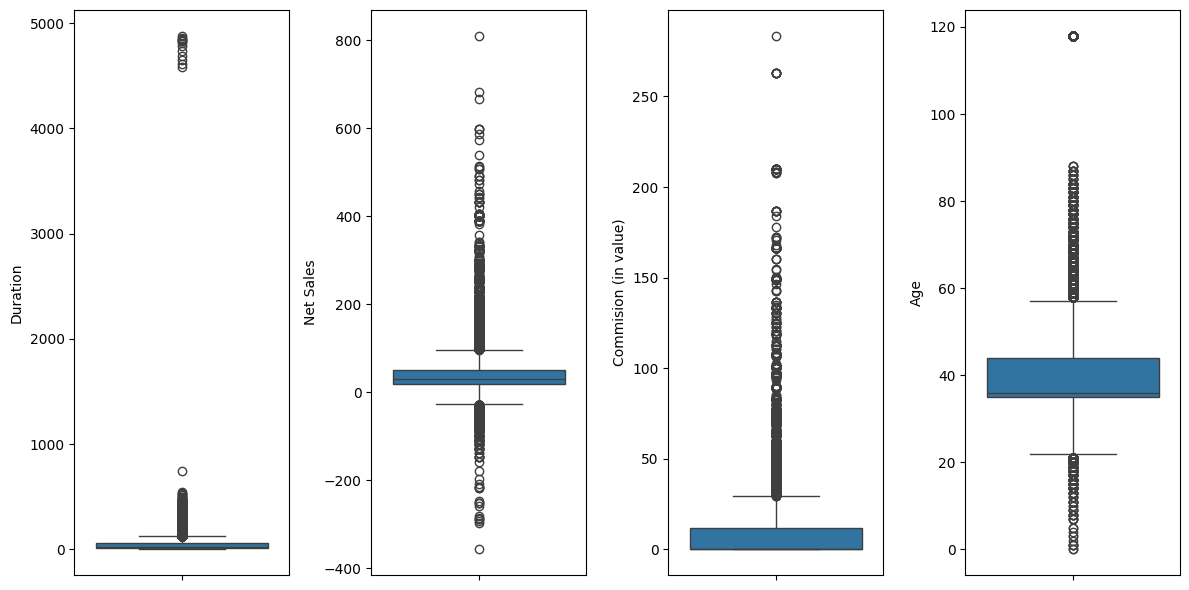

In [12]:
plt.figure(figsize=(12,6))
for idx, col in enumerate(numerical_cols,start=1):
    sns.boxplot(data = df[col], ax=plt.subplot(1,4,idx))
plt.tight_layout()
plt.show()

Although several features exhibit extreme values, outliers are not immediately removed at this stage. This decision is made based on the following considerations:
- Some extreme values may represent real-world scenarios, such as long-duration travel or high-value transactions.
- Removing outliers prematurely may result in loss of valuable information, especially for risk prediction tasks.

Instead, outlier handling will be addressed during the preprocessing stage using appropriate transformation techniques (e.g., scaling or transformation) within a pipeline to ensure consistency and avoid data leakage. While some outliers may represent valid real-world scenarios, certain values are considered unrealistic or potentially erroneous and may negatively impact model performance. Therefore, a rule-based filtering approach is applied to remove clearly invalid observations:
- Duration > 2000 days is considered unrealistic for travel duration
- Net Sales < 0 is removed, as negative sales values are not meaningful in this business context
- Age > 100 is excluded, as it is beyond typical human lifespan and may indicate data entry errors

In [ ]:
# Total rows
total_rows = df.shape[0]

# Count each condition BEFORE filtering (use original df before cleaning if needed)
duration_outliers = (df['Duration'] > 2000).sum()
net_sales_outliers = (df['Net Sales'] < 0).sum()
age_outliers = (df['Age'] > 100).sum()

# Calculate percentages
duration_pct = (duration_outliers / total_rows) * 100
net_sales_pct = (net_sales_outliers / total_rows) * 100
age_pct = (age_outliers / total_rows) * 100

# Print results
print(f"Duration > 2000: {duration_outliers} rows ({duration_pct:.2f}%)")
print(f"Net Sales < 0: {net_sales_outliers} rows ({net_sales_pct:.2f}%)")
print(f"Age > 100: {age_outliers} rows ({age_pct:.2f}%)")

Duration > 4000: 14 rows (0.04%)
Net Sales < 0: 478 rows (1.22%)
Age > 100: 423 rows (1.08%)


In [ ]:
# Apply outlier filtering
df = df[
    (df['Duration'] <= 2000) & 
    (df['Net Sales'] >= 0) & 
    (df['Age'] <= 100)
]

# Check number of rows after cleaning
after_rows = df.shape[0]

# Calculate removed rows
removed_rows = total_rows - after_rows
removed_percentage = (removed_rows / total_rows) * 100

# Display results
print(f"Rows before cleaning: {total_rows}")
print(f"Rows after cleaning: {after_rows}")
print(f"Rows removed: {removed_rows}")
print(f"Percentage removed: {removed_percentage:.2f}%")

Rows before cleaning: 39324
Rows after cleaning: 38419
Rows removed: 905
Percentage removed: 2.30%


The total proportion of unique rows removed after combining all conditions is 2.30%, indicating that only a small portion of the dataset is affected. This analysis confirms that:
- The applied filtering rules target only a small subset of extreme and potentially invalid data
- The majority of the dataset remains intact and representative of real-world scenarios
- The risk of losing important information is minimal

By quantifying the impact of each rule, we ensure that the data cleaning process is both transparent and justifiable, which is critical for maintaining trust in the modeling process.

# Section 4. Exploratory Data Analysis (EDA)

## 4.1 Target Distribution

The distribution of the target variable (Claim) is analyzed to understand the balance between classes.

In [15]:
df['Claim'].value_counts(normalize=True)

Claim
No     0.982665
Yes    0.017335
Name: proportion, dtype: float64

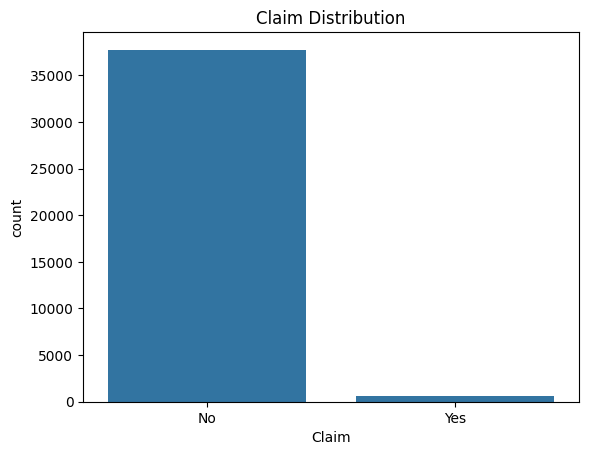

In [16]:
sns.countplot(x='Claim', data=df)
plt.title('Claim Distribution')
plt.show()

The dataset is highly imbalanced:
- Non-claim (No): 98.27%
- Claim (Yes): 1.73%

This indicates a severe class imbalance problem, where the number of claim cases is significantly lower than non-claim cases. From a business perspective (risk prediction), claim cases represent high-risk events and missing these cases (False Negatives) can lead to financial losses, therefore the modeling approach will prioritize Recall for the claim class. However, the extreme imbalanced dataset will be supported by additional metrics, such as F2 Score and PR AUC. Additionally, special techniques such as resampling and class weighting will be applied in later stages.

## 4.2 Numerical Features vs Target

To understand the relationship between numerical features and the target variable, we compare their distributions across claim and non-claim groups.

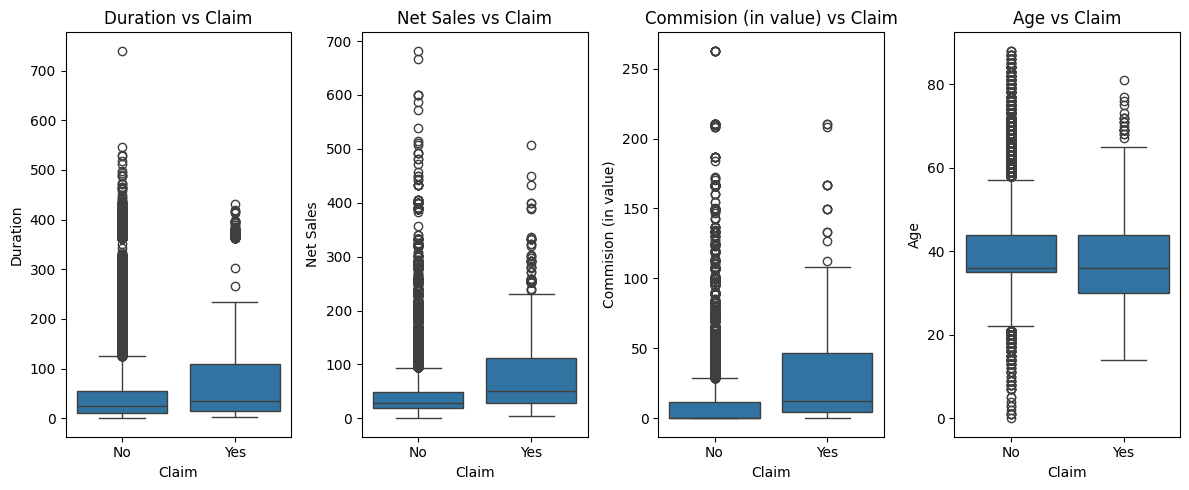

In [17]:
plt.figure(figsize=(12, 5))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(x='Claim', y=col, data=df)
    plt.title(f'{col} vs Claim')

plt.tight_layout()
plt.show()

In [18]:
df.groupby('Claim')[numerical_cols].mean()

,Duration,Net Sales,Commision (in value),Age
Claim,,,,
No,49.497629,42.416153,9.810588,39.007205
Yes,107.058559,93.701066,25.942613,37.756757


From the visualization:
- Customers with longer travel duration tend to show higher variability in claim occurrence
- Higher Net Sales and Commission values are associated with claim cases, suggesting that higher-value transactions may carry higher risk
- Age shows less clear separation, indicating weaker predictive power compared to financial and behavioral features

Analyzing numerical features helps identify which variables are likely to influence claim probability and whether feature transformation or scaling is needed. These features will be retained for modeling and further processed during feature engineering.

## 4.3 Categorical Features vs Target

Categorical variables are analyzed using claim rate (proportion of “Yes”) to better understand their relationship with claim behavior. For features with manageable cardinality (e.g., Agency, Product Name), all categories are visualized. For high-cardinality features such as Destination, only the top categories with the highest claim rates are displayed for clarity.

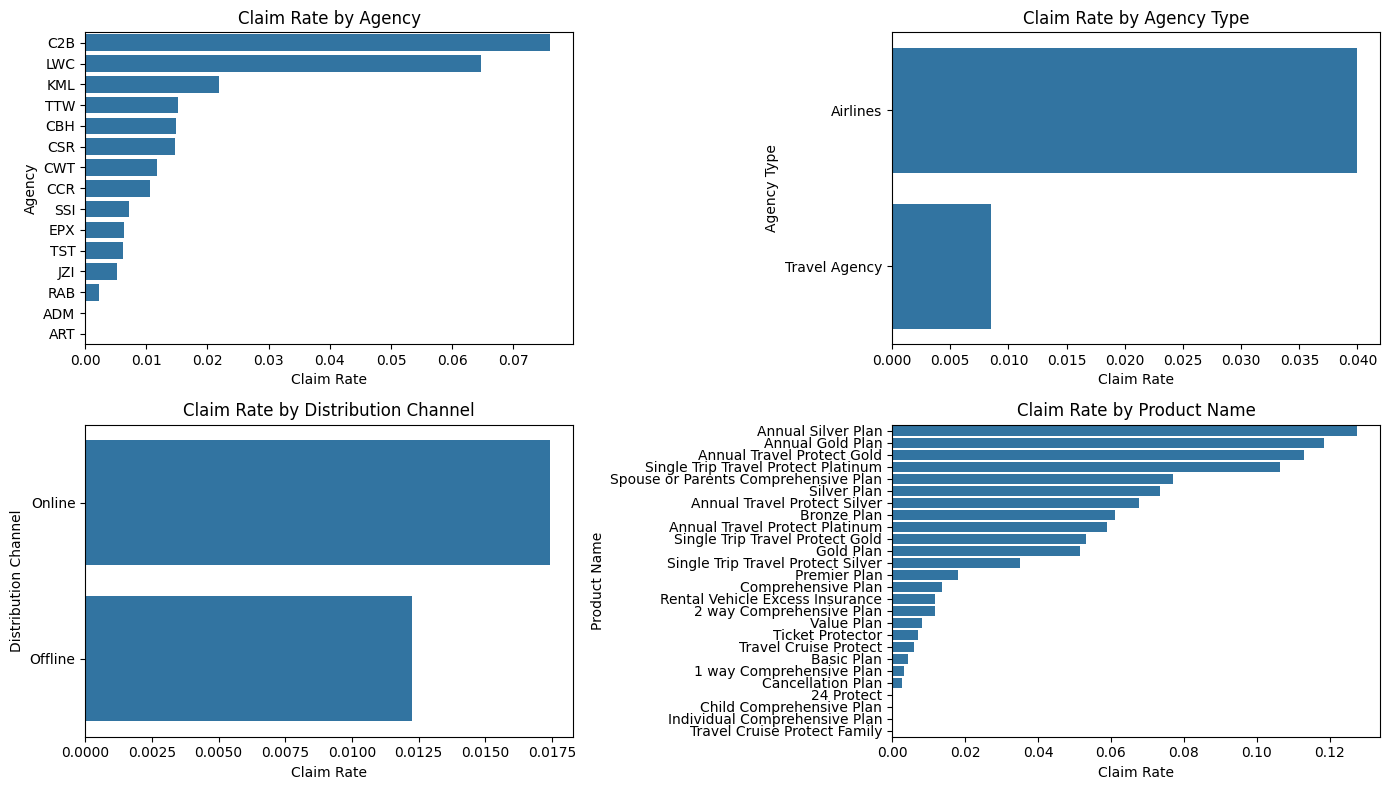

In [19]:
categorical_cols = ['Agency', 'Agency Type', 'Distribution Channel', 'Product Name']

plt.figure(figsize=(14, 8))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, i)
    
    claim_rate = df.groupby(col)['Claim'].apply(lambda x: (x == 'Yes').mean()).sort_values(ascending=False)
    
    sns.barplot(x=claim_rate.values, y=claim_rate.index)
    plt.title(f'Claim Rate by {col}')
    plt.xlabel('Claim Rate')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

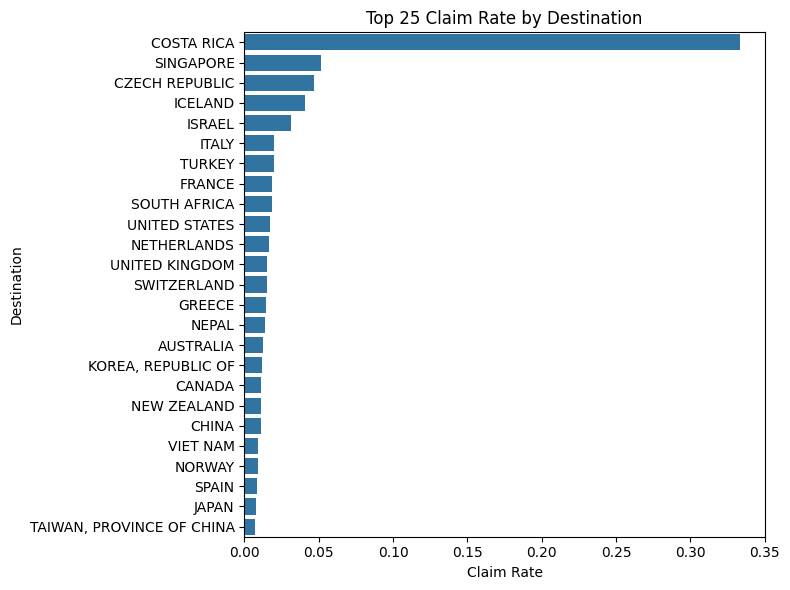

In [20]:
plt.figure(figsize=(8, 6))

claim_rate_dest = df.groupby('Destination')['Claim'].apply(lambda x: (x == 'Yes').mean())
top_dest = claim_rate_dest.sort_values(ascending=False).head(25)

sns.barplot(x=top_dest.values, y=top_dest.index)
plt.title('Top 25 Claim Rate by Destination')
plt.xlabel('Claim Rate')
plt.ylabel('Destination')

plt.tight_layout()
plt.show()

From the categorical analysis:
- Features such as Agency, Product Name, and Distribution Channel show variation in claim rates across categories, indicating differences in risk profiles.
- Certain categories consistently exhibit higher claim rates, suggesting potential high-risk segments.
- The Destination feature shows that specific travel locations are associated with higher claim likelihood.

This analysis indicates that:
- Categorical features provide meaningful signals for predicting claims
- Differences across categories may reflect underlying risk factors such as product coverage, customer profile, or travel conditions
- Proper encoding and potential grouping strategies will be necessary to effectively incorporate these features into the model

### 4.3.1 Handling Rare Categories in Destination

To address the high cardinality of the Destination feature, a grouping strategy is applied based on both frequency and claim occurrence.

Grouping Strategy:
- Destinations with fewer than 50 observations and no recorded claims are grouped into a single category labeled “Other”
- Destinations with at least one claim are retained, even if they have low frequency

This approach ensures that categories with insufficient data and no evidence of claim behavior are not treated as inherently low-risk. Instead, they are consolidated to reduce noise and improve model stability. At the same time, rare categories with observed claims are preserved, as they may represent meaningful risk signals.

In [21]:
dest_summary = df.groupby('Destination').agg(
    Count=('Destination', 'count'),
    Claim_Count=('Claim', lambda x: (x == 'Yes').sum())
).reset_index()

dest_summary.head()

,Destination,Count,Claim_Count
0,ANGOLA,1,0
1,ARGENTINA,13,0
2,ARMENIA,1,0
3,AUSTRALIA,2369,29
4,AUSTRIA,69,0


In [22]:
to_group = dest_summary[
    (dest_summary['Count'] < 50) & 
    (dest_summary['Claim_Count'] == 0)
]['Destination']

print(f"Number of destinations to group: {len(to_group)}")

Number of destinations to group: 90


In [23]:
rare_with_claim = dest_summary[
    (dest_summary['Count'] < 50) & 
    (dest_summary['Claim_Count'] > 0)
].sort_values(by='Claim_Count', ascending=False)

rare_with_claim.head(10)

,Destination,Count,Claim_Count
28,CZECH REPUBLIC,43,2
25,COSTA RICA,3,1
56,ISRAEL,32,1


In [24]:
df['Destination'] = df['Destination'].apply(lambda x: 'Other' if x in to_group.values else x)

In [25]:
# Check if 'Other' exists
print('Group category exists in (rows):',df['Destination'].value_counts()['Other'])

# Check unique count reduced
print('Destination unique values:',df['Destination'].nunique())

Group category exists in (rows): 717
Destination unique values: 47


During analysis, it was observed that a large number of rare destination categories (with fewer than 50 samples) exhibit a 0% claim rate. However, this does not necessarily indicate that these destinations are truly low-risk. Instead, it is likely due to the limited number of observations, especially given the highly imbalanced nature of the dataset.

The Destination feature is transformed by grouping rare categories directly into an “Other” category based on the defined criteria. The transformation is applied directly to the original column to simplify the dataset structure, as the grouping strategy has been finalized during the exploratory analysis phase.

## 4.4 Correlation Analysis (Numerical)

A correlation matrix is used to examine relationships between numerical features.

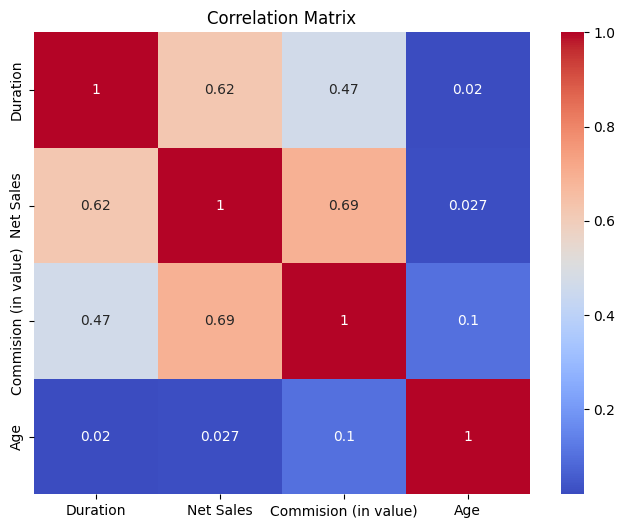

In [26]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Some features, such as Net Sales and Commission, may show strong correlation. This indicates potential redundancy between variables.

Understanding correlation is important because highly correlated features may introduce multicollinearity and this can negatively affect models such as Logistic Regression. If necessary, feature selection or dimensionality reduction techniques will be considered in later stages.

# **Section 5. Data Preparation**

## 5.1 Define Feature and Target

In [27]:
# Convert Claim (Yes/No) → 0/1
df['Claim'] = df['Claim'].map({'No': 0, 'Yes': 1})

In [28]:
# Define Feature and Target
x = df.drop(columns='Claim')
y = df['Claim']

## 5.2 Split Data into Train and Test Set

In [29]:
# Split dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# Reset index
x_train.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)
x_test.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

# Overview
print("Feature shape (train): ", x_train.shape)
print("Target shape (train): ", y_train.shape)
x_train.head()

Feature shape (train):  (30735, 9)
Target shape (train):  (30735,)


,Agency,Agency Type,Distribution Channel,Product Name,Duration,Destination,Net Sales,Commision (in value),Age
0,JZI,Airlines,Online,Value Plan,25,CHINA,0.0,20.30,80
1,TTW,Travel Agency,Offline,Child Comprehensive Plan,364,SINGAPORE,74.0,0.00,16
2,KML,Travel Agency,Online,Value Plan,75,NETHERLANDS,109.0,41.42,48
3,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,11,UNITED STATES,19.8,11.88,36
4,JZI,Airlines,Online,Basic Plan,38,HONG KONG,26.0,9.10,48


# **Section 6. Feature Engineering**

The feature engineering performed in here are:
1. Numerical features (Duration, Net Sales, Commission, Age) are imputed using median and scaled using RobustScaler due to the presence of outliers.
2. Categorical features with low-to-moderate cardinality (Agency, Agency Type, Distribution Channel, Product Name) are encoded using OneHotEncoder. This approach preserves interpretability and allows the model to capture category-specific patterns. Some considerations were taken for moderate cardinality (Agency and Product Name), but some tests that have been run previously show worse evaluation metric using BinaryEncoder, therefore it is decided to use OneHotEncoder for these features.
3. High-cardinality feature (Destination) is encoded using BinaryEncoder to reduce dimensionality while preserving information.

## 6.1 Build Columns Transformer

In [30]:
# Feature Engineering Method Initialization
robust = RobustScaler()
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')    
be = BinaryEncoder()

imputation_numeric = SimpleImputer(strategy='median')
imputation_categoric = SimpleImputer(strategy='constant', fill_value='unknown')

In [ ]:
# Group each feature
numerical_feature = ['Duration', 'Net Sales', 'Commision (in value)', 'Age']
cat_ohe_feature = ['Agency', 'Agency Type', 'Distribution Channel', 'Product Name']
cat_binary_feature = ['Destination']

In [32]:
# Numerical pipeline
num_pipeline = Pipeline([
    ('imputer', imputation_numeric),
    ('scaler', robust)
])

# OneHot categorical pipeline
cat_ohe_pipeline = Pipeline([
    ('imputer', imputation_categoric),
    ('encoder', ohe)
])

# Binary categorical pipeline
cat_binary_pipeline = Pipeline([
    ('imputer', imputation_categoric),
    ('encoder', be)
])

In [ ]:
# Column Transformer Build
fe = ColumnTransformer(transformers=[
    ('numerical_scaling', num_pipeline, numerical_feature),
    ('ohe_encoding', cat_ohe_pipeline, cat_ohe_feature),
    ('binary_encoding', cat_binary_pipeline, cat_binary_feature)        
], remainder='drop', verbose_feature_names_out=False)

## 6.2 Dataset Overview (After Feature Engineering)

In [34]:
# Fitting Process
fe.fit(x_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical_scaling', ...), ('ohe_encoding', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` 

In [35]:
# Transformation Process
x_train_pre = fe.transform(x_train)
x_train_pre = pd.DataFrame(x_train_pre, columns=fe.get_feature_names_out())

x_test_pre = fe.transform(x_test)
x_test_pre = pd.DataFrame(x_test_pre, columns=fe.get_feature_names_out())

In [36]:
display(x_train_pre.head())
display(x_test_pre.head())

,Duration,Net Sales,Commision (in value),Age,Agency_ART,Agency_C2B,Agency_CBH,Agency_CCR,Agency_CSR,Agency_CWT,...,Product Name_Spouse or Parents Comprehensive Plan,Product Name_Ticket Protector,Product Name_Travel Cruise Protect,Product Name_Value Plan,0_0,0_1,0_2,0_3,0_4,0_5
0,0.000000,-0.960265,1.708754,4.4,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,7.369565,1.490066,0.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1.086957,2.649007,3.486532,1.2,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
3,-0.304348,-0.304636,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.282609,-0.099338,0.765993,1.2,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


,Duration,Net Sales,Commision (in value),Age,Agency_ART,Agency_C2B,Agency_CBH,Agency_CCR,Agency_CSR,Agency_CWT,...,Product Name_Spouse or Parents Comprehensive Plan,Product Name_Ticket Protector,Product Name_Travel Cruise Protect,Product Name_Value Plan,0_0,0_1,0_2,0_3,0_4,0_5
0,-0.347826,0.662252,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.543478,-0.932450,0.020202,1.2,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,7.391304,6.216887,4.561448,1.2,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.217391,0.589404,0.984848,-0.2,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,3.000000,0.132450,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0


# **Section 7. Model Benchmarking**

In this section, we evaluate several baseline classification models using default parameters. The goal is to identify which models perform best in detecting claim cases (minority class). Given the highly imbalanced dataset (1.7% claim rate), the primary evaluation metric is Recall for the positive class (Claim = Yes), as minimizing false negatives is critical for risk control. Additional metrics such as PR-AUC, Precision, and F2-score are also evaluated to ensure balanced performance.

Since our dataset is extremely imbalanced, XGBoost and LightGBM have a parameter called scale_pos_weight that enable us to drive Recall by forcing the model to treat every missed claim as numerous times more "painful" than a false alarm. We will incorporate this parameter.

In addition to evaluating baseline models, we incorporate feature selection using SelectPercentile to assess whether reducing the number of features improves model performance. We experiment with different percentile values (50%, 75%, 100%) and observe performance trends, particularly for Recall, which is the primary metric for detecting claim cases. This step helps determine whether feature reduction enhances generalization or removes important signals from the minority class.

## 7.1 Baseline Model

In [37]:
# Setting random_state = 42 to ensure reproducibility
RANDOM_STATE = 42

In [38]:
# Define scale_pos_weight: the ratio of "No" to "Yes" cases for XGBoost and LightGBM
ratio = df['Claim'].value_counts()

# 0 is No, 1 is Yes
scale_pos_weight = ratio.loc[0] / ratio.loc[1]

print(f"Ratio: {scale_pos_weight:.2f}")

Ratio: 56.69


In [39]:
models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE),
    'LightGBM': LGBMClassifier(random_state=RANDOM_STATE, scale_pos_weight=scale_pos_weight),
    'XGBoost': XGBClassifier(random_state=RANDOM_STATE, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=scale_pos_weight)
}

In [40]:
scoring = {
    'recall': make_scorer(recall_score),
    'precision': make_scorer(precision_score),
    'f2': make_scorer(fbeta_score, beta=2),
    'pr_auc': make_scorer(average_precision_score)
}

In [41]:
# Setting percentiles for Feature Selection
percentiles = [50, 75, 100]

In [42]:
# Stratified KFold to ensure same proportion of class in every fold
skfold = StratifiedKFold(n_splits=5)

In [43]:
results = []

for name, model in models.items():
    for p in percentiles:
        
        pipe = Pipeline([
            ('preprocess', fe),
            ('feature_selection', SelectPercentile(score_func=f_classif, percentile=p)),
            ('model', model)
        ])
        
        cv_results = cross_validate(
            pipe,
            x_train,
            y_train,
            cv=skfold,
            scoring=scoring,
            return_train_score=False
        )
        
        results.append({
            'Model': name,
            'Percentile': p,
            'Recall': cv_results['test_recall'].mean(),
            'Precision': cv_results['test_precision'].mean(),
            'F2': cv_results['test_f2'].mean(),
            'PR_AUC': cv_results['test_pr_auc'].mean()
        })

[LightGBM] [Info] Number of positive: 427, number of negative: 24161
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002792 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 868
[LightGBM] [Info] Number of data points in the train set: 24588, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.017366 -> initscore=-4.035711
[LightGBM] [Info] Start training from score -4.035711
[LightGBM] [Info] Number of positive: 427, number of negative: 24161
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002353 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 785
[LightGBM] [Info] Number of data points in the train set: 24588, number of used features: 24
[LightGBM] [Info] [binar

In [44]:
benchmark_df = pd.DataFrame(results).sort_values(by='Recall', ascending=False)
benchmark_df

,Model,Percentile,Recall,Precision,F2,PR_AUC
14,LightGBM,100,0.459707,0.069142,0.215490,0.041161
12,LightGBM,50,0.455898,0.061354,0.199285,0.037522
13,LightGBM,75,0.437154,0.066704,0.206793,0.039125
15,XGBoost,50,0.328249,0.067389,0.184284,0.035274
17,XGBoost,100,0.315183,0.074304,0.190765,0.036207
16,XGBoost,75,0.283301,0.069658,0.175228,0.032722
8,Decision Tree,100,0.086281,0.065224,0.080892,0.021626
7,Decision Tree,75,0.078787,0.062065,0.074696,0.021114
6,Decision Tree,50,0.061929,0.061342,0.061129,0.020341
10,Random Forest,75,0.015024,0.070575,0.017824,0.018565


Based on the benchmarking results, LightGBM consistently achieves the highest recall among all baseline models. This indicates that LightGBM is more capable of capturing patterns related to claim occurrences (minority class), which aligns with the primary business objective of minimizing false negatives.

Additionally, LightGBM also demonstrates competitive performance in PR-AUC and F2-score, suggesting a better balance between detecting claims and maintaining reasonable precision. Therefore, LightGBM is selected as the primary candidate for further optimization. However, it is noticed that these models have very low precision, which could lead to excessive false positives. This trade-off can negatively impact operational efficiency. Therefore, the evaluation focus is adjusted to prioritize a better balance between recall and precision, using F2-score as the primary metric while still ensuring recall remains sufficiently high.

In [45]:
best_model_name = benchmark_df.iloc[0]['Model']
best_model = models[best_model_name]
best_model

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## 7.2 Model Modification: Imbalanced Handling

Given that only 1.7% of the data belongs to the positive class (Claim = Yes), imbalance handling is essential. Resampling techniques are applied to improve model sensitivity toward the minority class. RandomOverSampler increases minority representation but risks overfitting. RandomUnderSampler reduces imbalance by removing majority samples but may lose information. SMOTE generates synthetic samples to improve generalization, though it may introduce noise.

We evaluate two approaches:
1. Resampling methods (ROS, RUS, SMOTE)
2. Penalized models using class_weight='balanced'

The goal is to improve Recall while maintaining reasonable precision.

In [46]:
resamplers = {
    'ROS': RandomOverSampler(random_state=RANDOM_STATE),
    'RUS': RandomUnderSampler(random_state=RANDOM_STATE),
    'SMOTE': SMOTE(random_state=RANDOM_STATE)
}

In [47]:
resampling_results = []

for name, sampler in resamplers.items():
    
    pipe = ImbPipeline([
        ('preprocess', fe),
        ('resample', sampler),
        ('model', best_model)
    ])
    
    cv_results = cross_validate(
        pipe,
        x_train,
        y_train,
        cv=skfold,
        scoring=scoring
    )
    
    resampling_results.append({
        'Method': name,
        'Recall': cv_results['test_recall'].mean(),
        'Precision': cv_results['test_precision'].mean(),
        'F2': cv_results['test_f2'].mean(),
        'PR_AUC': cv_results['test_pr_auc'].mean()
    })

[LightGBM] [Info] Number of positive: 24161, number of negative: 24161
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002610 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 836
[LightGBM] [Info] Number of data points in the train set: 48322, number of used features: 49
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 24161, number of negative: 24161
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002578 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 810
[LightGBM] [Info] Number of data points in the train set: 48322, number of used features: 49
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000

In [48]:
penalized_model = best_model.__class__(**best_model.get_params())
penalized_model.set_params(class_weight='balanced')

pipe_penalized = Pipeline([
    ('preprocess', fe),
    ('model', penalized_model)
])

cv_results = cross_validate(
    pipe_penalized,
    x_train,
    y_train,
    cv=skfold,
    scoring=scoring
)

penalized_result = {
    'Method': 'Class Weight Balanced',
    'Recall': cv_results['test_recall'].mean(),
    'Precision': cv_results['test_precision'].mean(),
    'F2': cv_results['test_f2'].mean(),
    'PR_AUC': cv_results['test_pr_auc'].mean()
}

[LightGBM] [Info] Number of positive: 427, number of negative: 24161
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000987 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 916
[LightGBM] [Info] Number of data points in the train set: 24588, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 427, number of negative: 24161
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000950 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 910
[LightGBM] [Info] Number of data points in the train set: 24588, number of used features: 48
[LightGBM] [Info] [binar

## 7.3 Model Comparison

In this section, we compare:
- Baseline model
- Resampling techniques
- Penalized model

The evaluation focuses on Recall as the primary metric, supported by PR-AUC, Precision, and F2-score.

In [49]:
resampling_df = pd.DataFrame(resampling_results)
penalized_df = pd.DataFrame([penalized_result])

comparison_df = pd.concat([
    benchmark_df.head(1).rename(columns={'Model': 'Method'}),
    resampling_df,
    penalized_df
], ignore_index=True)

comparison_df.sort_values(by='F2', ascending=False)

,Method,Percentile,Recall,Precision,F2,PR_AUC
0,LightGBM,100.0,0.459707,0.069142,0.215490,0.041161
3,SMOTE,NaN,0.647364,0.044081,0.173201,0.034699
1,ROS,NaN,0.682931,0.038330,0.156487,0.031932
4,Class Weight Balanced,NaN,0.682984,0.037901,0.155044,0.031453
2,RUS,NaN,0.924987,0.024259,0.109773,0.023751


Although resampling techniques such as Random Under Sampling (RUS) and SMOTE significantly improve recall, they result in extremely low precision, leading to a high number of false positives. This trade-off is not ideal from a business perspective, as excessive false alarms can increase operational costs and reduce efficiency.

Similarly, penalized models using class_weight='balanced' improve recall but do not outperform LightGBM in terms of F2-score, which better reflects the balance between recall and precision. 

LightGBM, combined with scale_pos_weight, provides a more stable and balanced performance without altering the original data distribution. Unlike SMOTE, which creates synthetic examples that might not represent real-world insurance claim patterns, LightGBM learns directly from the original imbalance. This reduces the risk of the model learning 'artifacts' or unrealistic noise that could lead to poor performance on truly unseen data. Therefore, LightGBM is selected as the final model for hyperparameter tuning.

# Section 8. Hyperparameter Tuning

In this section, we optimize the performance of the selected model (LightGBM) using RandomizedSearchCV. The objective is to improve the model’s ability to detect claim cases (minority class), while maintaining a reasonable balance with precision.

Given the business focus on minimizing false negatives, the evaluation metric used for tuning is F2-score, which emphasizes recall more than precision. We also incorporate scale_pos_weight to handle class imbalance without altering the dataset structure. RandomizedSearchCV is chosen instead of GridSearchCV for efficiency, as it explores the parameter space more effectively within a limited number of iterations.

In [50]:
# best model
lgbm = LGBMClassifier(
    random_state=RANDOM_STATE,
    scale_pos_weight=scale_pos_weight
)

pipe = Pipeline([
    ('preprocess', fe),
    ('model', lgbm)
])

The selected hyperparameter space is designed to balance model complexity, generalization, and computational efficiency.

- n_estimators and learning_rate are tuned together to control the learning process. A lower learning rate typically requires more estimators but leads to better generalization.
- num_leaves and max_depth control the complexity of the tree structure. These parameters are critical in capturing non-linear relationships while avoiding overfitting.
- min_child_samples ensures that splits occur only when sufficient data is available, improving model robustness.
- subsample and colsample_bytree introduce randomness during training, which helps reduce overfitting and improves generalization.
- reg_alpha and reg_lambda are regularization parameters that help stabilize the model, especially in noisy or imbalanced datasets.

Overall, the parameter space is designed to explore meaningful variations in model behavior without introducing unnecessary computational overhead.

In [51]:
# Define Parameter Space
param_dist = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__num_leaves': [15, 31, 63, 127],
    'model__max_depth': [-1, 5, 10, 20],
    'model__min_child_samples': [10, 20, 30, 50],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__reg_alpha': [0, 0.1, 1],
    'model__reg_lambda': [0, 0.1, 1]
}

In [52]:
f2_scorer = make_scorer(fbeta_score, beta=2)

RandomizedSearchCV is chosen over GridSearchCV due to its efficiency in exploring the hyperparameter space. Given the relatively large parameter space, GridSearchCV would require evaluating all possible combinations, resulting in significant computational cost.

In contrast, RandomizedSearchCV samples a fixed number of parameter combinations, allowing for a broader exploration of the search space within a limited time. This approach provides a good balance between optimization performance and computational efficiency, making it suitable for this use case.

In [53]:
random_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=50,
    scoring=f2_scorer,
    cv=skfold,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search.fit(x_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[LightGBM] [Info] Number of positive: 533, number of negative: 30202
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001629 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 912
[LightGBM] [Info] Number of data points in the train set: 30735, number of used features: 47
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.017342 -> initscore=-4.037142
[LightGBM] [Info] Start training from score -4.037142
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...186186184)))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.6, 0.8, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [-1, 5, ...], 'model__min_child_samples': [10, 20, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","make_scorer(f...dict', beta=2)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for 

In [54]:
best_model = random_search.best_estimator_

print("Best Params:")
print(random_search.best_params_)

print("\nBest F2 Score:")
print(random_search.best_score_)

Best Params:
{'model__subsample': 1.0, 'model__reg_lambda': 0, 'model__reg_alpha': 1, 'model__num_leaves': 31, 'model__n_estimators': 200, 'model__min_child_samples': 30, 'model__max_depth': 5, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.6}

Best F2 Score:
0.2517408089396749


In [55]:
best_params_df = pd.DataFrame([random_search.best_params_])
best_params_df.T.rename(columns={0: 'Best Value'})

,Best Value
model__subsample,1.00
model__reg_lambda,0.00
model__reg_alpha,1.00
model__num_leaves,31.00
model__n_estimators,200.00
model__min_child_samples,30.00
model__max_depth,5.00
model__learning_rate,0.01
model__colsample_bytree,0.60


In [56]:
# Recall and F2 before
baseline_row = benchmark_df[
    (benchmark_df['Model'] == 'LightGBM') &
    (benchmark_df['Percentile'] == 100)
][['Recall', 'F2']]

baseline_row = baseline_row.rename(columns={
    'Recall': 'Recall_Before',
    'F2': 'F2_Before'
})

In [57]:
tuned_cv = cross_validate(
    best_model,
    x_train,
    y_train,
    cv=skfold,
    scoring={
        'recall': make_scorer(recall_score),
        'f2': make_scorer(fbeta_score, beta=2)
    }
)

tuned_df = pd.DataFrame({
    'Recall_After': [tuned_cv['test_recall'].mean()],
    'F2_After': [tuned_cv['test_f2'].mean()]
})

[LightGBM] [Info] Number of positive: 427, number of negative: 24161
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003033 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 914
[LightGBM] [Info] Number of data points in the train set: 24588, number of used features: 47
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.017366 -> initscore=-4.035711
[LightGBM] [Info] Start training from score -4.035711
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [58]:
comparison_df = pd.concat([baseline_row.reset_index(drop=True), tuned_df], axis=1)
comparison_df

,Recall_Before,F2_Before,Recall_After,F2_After
0,0.459707,0.21549,0.613595,0.251741


The tuned LightGBM model shows an improvement in F2-score, indicating a better balance between recall and precision. While recall may not increase significantly, the improvement in F2 suggests that the model is making more efficient predictions, reducing unnecessary false positives while still capturing a substantial portion of claim cases.

# Section 9. Model Evaluation

## 9.1 Threshold Analysis

Threshold tuning was performed to identify the optimal balance between recall and precision. To ensure that the selected threshold generalizes well, performance on both training and test data is evaluated across a range of thresholds.

In [59]:
thresholds = np.arange(0.01, 0.5, 0.01)

train_results = []
test_results = []

# TRAIN probabilities
y_proba_train = best_model.predict_proba(x_train)[:,1]

# TEST probabilities
y_proba_test = best_model.predict_proba(x_test)[:,1]

for t in thresholds:
    # TRAIN
    y_pred_train = (y_proba_train >= t).astype(int)
    
    train_results.append({
        'Threshold': t,
        'Recall_Train': recall_score(y_train, y_pred_train),
        'F2_Train': fbeta_score(y_train, y_pred_train, beta=2)
    })
    
    # TEST
    y_pred_test = (y_proba_test >= t).astype(int)
    
    test_results.append({
        'Threshold': t,
        'Recall_Test': recall_score(y_test, y_pred_test),
        'F2_Test': fbeta_score(y_test, y_pred_test, beta=2)
    })

train_df = pd.DataFrame(train_results)
test_df = pd.DataFrame(test_results)

# merge
plot_df = train_df.merge(test_df, on='Threshold')
plot_df.head(10)

,Threshold,Recall_Train,F2_Train,Recall_Test,F2_Test
0,0.01,1.000000,0.081084,1.000000,0.080940
1,0.02,1.000000,0.081272,1.000000,0.081088
2,0.03,1.000000,0.082063,1.000000,0.081886
3,0.04,1.000000,0.083425,0.992481,0.082603
4,0.05,1.000000,0.084635,0.992481,0.083820
5,0.06,1.000000,0.086949,0.984962,0.085632
6,0.07,1.000000,0.090474,0.984962,0.089383
7,0.08,1.000000,0.094550,0.977444,0.092474
8,0.09,0.998124,0.098471,0.969925,0.095854
9,0.10,0.998124,0.102953,0.969925,0.100703


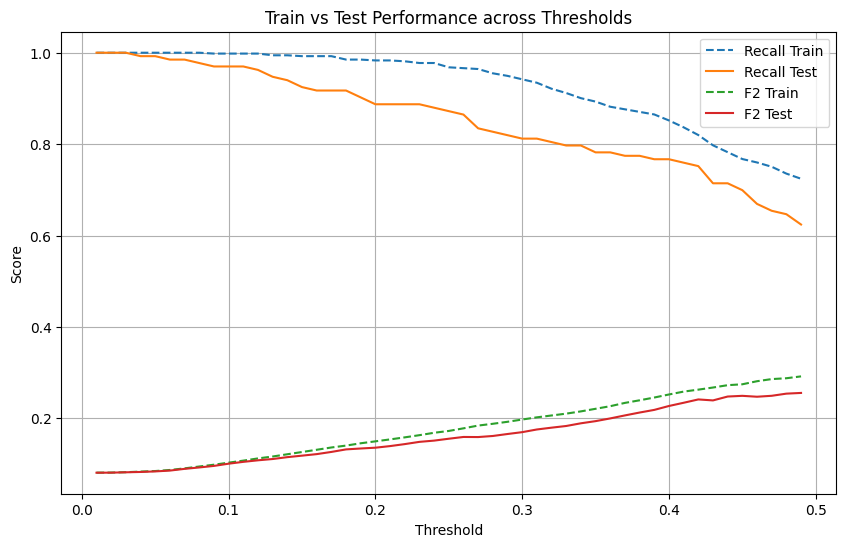

In [60]:
plt.figure(figsize=(10,6))

# Recall
plt.plot(plot_df['Threshold'], plot_df['Recall_Train'], label='Recall Train', linestyle='--')
plt.plot(plot_df['Threshold'], plot_df['Recall_Test'], label='Recall Test')

# F2
plt.plot(plot_df['Threshold'], plot_df['F2_Train'], label='F2 Train', linestyle='--')
plt.plot(plot_df['Threshold'], plot_df['F2_Test'], label='F2 Test')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Train vs Test Performance across Thresholds')
plt.legend()
plt.grid()
plt.show()

The results show that:
- The gap between training and test curves is relatively small, indicating that the model does not suffer from significant overfitting.
- Recall decreases as the threshold increases, while F2-score reaches an optimal point before declining.
- The selected threshold lies in a region where both recall and F2-score remain stable across training and test sets.

Lower thresholds significantly increase recall but lead to a substantial drop in precision, resulting in excessive false positives. Conversely, higher thresholds improve precision but reduce the model’s ability to detect actual claim cases.

Based on the evaluation results, a threshold in the range of approximately 0.30-0.35 was identified as the optimal trade-off point, where recall remains high while precision shows meaningful improvement. This threshold, specifically 0.34, is selected as the final decision boundary for the model.

## 9.2 Model Comparison on Test Set

To ensure a fair evaluation, multiple modeling approaches are compared on the test set:

1. Baseline model (LightGBM without tuning)
2. Resampling approach
3. Penalized model (class_weight / scale_pos_weight)
4. Tuned model (RandomizedSearchCV)

This comparison ensures that the selected model is not only optimal during training but also generalizes well to unseen data. PR-AUC is included as a validation metric to confirm that the model maintains good ranking performance on imbalanced data and does not exhibit signs of overfitting or data leakage.

In [61]:
from sklearn.metrics import recall_score, precision_score, fbeta_score, average_precision_score

threshold = 0.34

def evaluate_model(model, X, y, threshold):
    y_proba = model.predict_proba(X)[:,1]
    y_pred = (y_proba >= threshold).astype(int)
    
    return {
        'Recall': recall_score(y, y_pred),
        'Precision': precision_score(y, y_pred),
        'F2': fbeta_score(y, y_pred, beta=2),
        'PR_AUC': average_precision_score(y, y_proba)
    }

In [62]:
baseline_model = LGBMClassifier(random_state=42)
baseline_pipe = Pipeline([
    ('preprocess', fe),
    ('model', baseline_model)
])

baseline_pipe.fit(x_train, y_train)
baseline_result = evaluate_model(baseline_pipe, x_test, y_test, threshold)

[LightGBM] [Info] Number of positive: 533, number of negative: 30202
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001082 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 914
[LightGBM] [Info] Number of data points in the train set: 30735, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.017342 -> initscore=-4.037142
[LightGBM] [Info] Start training from score -4.037142


In [63]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

resample_pipe = ImbPipeline([
    ('preprocess', fe),
    ('resample', RandomUnderSampler(random_state=42)),
    ('model', LGBMClassifier(random_state=42))
])

resample_pipe.fit(x_train, y_train)
resample_result = evaluate_model(resample_pipe, x_test, y_test, threshold)

[LightGBM] [Info] Number of positive: 533, number of negative: 533
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000219 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 450
[LightGBM] [Info] Number of data points in the train set: 1066, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


In [64]:
penalized_model = LGBMClassifier(
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

penalized_pipe = Pipeline([
    ('preprocess', fe),
    ('model', penalized_model)
])

penalized_pipe.fit(x_train, y_train)
penalized_result = evaluate_model(penalized_pipe, x_test, y_test, threshold)

[LightGBM] [Info] Number of positive: 533, number of negative: 30202
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001233 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 914
[LightGBM] [Info] Number of data points in the train set: 30735, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.017342 -> initscore=-4.037142
[LightGBM] [Info] Start training from score -4.037142


In [65]:
tuned_result = evaluate_model(best_model, x_test, y_test, threshold)

In [66]:
comparison_all = pd.DataFrame([
    {'Model': 'Baseline', **baseline_result},
    {'Model': 'Resampling', **resample_result},
    {'Model': 'Penalized', **penalized_result},
    {'Model': 'Tuned', **tuned_result}
])

comparison_all.sort_values(by='F2', ascending=False)

,Model,Recall,Precision,F2,PR_AUC
3,Tuned,0.796992,0.046675,0.189083,0.093404
2,Penalized,0.616541,0.049072,0.186110,0.087433
1,Resampling,0.804511,0.037676,0.158660,0.067479
0,Baseline,0.015038,0.125000,0.018248,0.081494


The results shows that:
- The tuned LightGBM model achieves the best overall performance in terms of F2-score while maintaining competitive recall.
- Although resampling methods achieve higher recall, they significantly reduce precision, leading to excessive false positives. 
- The penalized model improves recall compared to the baseline but does not outperform the tuned model in terms of overall balance.

Additionally, PR-AUC results confirm that the tuned model maintains good ranking performance, indicating no significant overfitting or data leakage. Therefore, the tuned LightGBM model is selected as the final model for deployment.

## 9.3. Model Interpretability

In this section, we evaluate whether the model can be trusted for real-world application.

The evaluation focuses on:
1. Confusion Matrix to understand prediction behavior
2. Cost-benefit analysis to assess business impact
3. Model interpretability using SHAP to explain prediction drivers

The goal is to ensure that the model is not only accurate but also reliable, interpretable, and aligned with business objectives.

### 9.3.1 Confusion Matrix

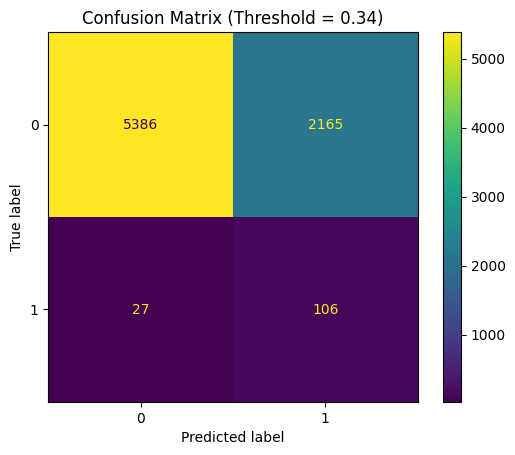

In [67]:
y_proba = best_model.predict_proba(x_test)[:,1]
y_pred = (y_proba >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix (Threshold = 0.34)")
plt.show()

The confusion matrix provides insight into how the model makes predictions:

- True Positives (TP): Correctly identified claim cases
- False Negatives (FN): Missed claim cases (critical risk)
- False Positives (FP): Non-claim cases predicted as claim
- True Negatives (TN): Correctly identified non-claim cases

With the selected threshold (0.34), the model achieves a strong balance:
- A high number of true positives, indicating effective detection of claim cases
- A controlled number of false negatives, reducing financial risk
- Some false positives are present, which is acceptable under a balanced operational strategy

This aligns with the business goal of minimizing missed claims while maintaining operational efficiency.

### 9.3.2 Cost-Benefit Analysis

To evaluate the business impact of our model, we transform the technical metrics (Confusion Matrix) into a financial framework. We compare the Baseline Scenario (No Model) against our tuned model. First, we categorize the financial impact into two distinct types:

1. Direct Operational Costs (Immediate Impact)
- False Negative (High Impact): Costs stemming from financial unpreparedness, such as high-interest emergency borrowing to cover claims, manual expedited processing, and liquidity risks. We assume an additional penalty of 20% of the claim value.
- False Positive (Low Impact): Costs of additional verification or administrative screening. We assume $5 per case.

2. Strategic Opportunity Costs (Long-term Impact)
- False Positive (Capital Lock-up): Capital reserved for predicted claims that never materialize cannot be used for investments. Assuming a 5% annual investment return on the reserved funds.
- False Negative (Reputational Risk): Poor claim handling due to lack of readiness leads to lower customer retention. Acquiring a new customer is roughly 5x more expensive than retaining one.

Second, we set our financial assumptions. Based on the insurance portfolio and industry standards:
- Average Net Sales: $40 (Revenue per policy)
- Average Claim Payout: $1,500 (Liability per claim)
- Liquidity/Penalty Cost per FN: $300 (20% of $1,500)
- Opportunity Cost per FP: $75 (5% of the $1,500 reserve)
- Administrative Cost per FP: $5

In [68]:
# 1. Input Values (Confusion Matrix & Financial Assumptions)
tp, fp, fn, tn = 106, 2165, 27, 5386
claim_payout = 1500
fn_penalty = 300       # 20% Liquidity/Reputation Penalty
fp_admin_cost = 5      # Reduced Administrative Review Cost
fp_opp_cost = 75       # 5% Opportunity Cost on $1,500 Reserve

# 2. Calculations
total_actual_claims = tp + fn
baseline_cost = total_actual_claims * (claim_payout + fn_penalty)
model_fn_cost = fn * (claim_payout + fn_penalty)
model_fp_cost = fp * (fp_admin_cost + fp_opp_cost)
model_cost = model_fn_cost + model_fp_cost

# 3. Create Comparison DataFrame
cba_data = {
    'Metric': [
        'Anticipated Claims (TP)', 
        'Missed Claims (FN)', 
        'False Alarms (FP)', 
        'Financial Risk from FN (Payout + Penalty)', 
        'Operational Cost from FP (Admin + Opp. Cost)', 
        'Total Risk-Related Cost'
    ],
    'Baseline Scenario (No Model)': [
        0, 
        total_actual_claims, 
        0, 
        f"${baseline_cost:,.0f}", 
        "$0", 
        f"${baseline_cost:,.0f}"
    ],
    'Tuned Model Scenario': [
        tp, 
        fn, 
        fp, 
        f"${model_fn_cost:,.0f}", 
        f"${model_fp_cost:,.0f}", 
        f"${model_cost:,.0f}"
    ]
}

df_cba = pd.DataFrame(cba_data)
df_cba

,Metric,Baseline Scenario (No Model),Tuned Model Scenario
0,Anticipated Claims (TP),0,106
1,Missed Claims (FN),133,27
2,False Alarms (FP),0,2165
3,Financial Risk from FN (Payout + Penalty),"$239,400","$48,600"
4,Operational Cost from FP (Admin + Opp. Cost),$0,"$173,200"
5,Total Risk-Related Cost,"$239,400","$221,800"


In [69]:
cost_savings = baseline_cost - model_cost
cost_reduction_pct = cost_savings / baseline_cost * 100

impact_df = pd.DataFrame({
    'Metric': ['Cost Savings', 'Cost Reduction (%)'],
    'Value': [
        f"${cost_savings:,.0f}",
        f"{cost_reduction_pct:.2f}%"
    ]
})

impact_df

,Metric,Value
0,Cost Savings,"$17,600"
1,Cost Reduction (%),7.35%


By shifting from a "Predict All No" strategy to the tuned model, the business achieves three major goals:
1. Risk Shift: We trade unpredictable, high-impact losses (False Negatives) for predictable, manageable operational expenses (False Positives).
2. Liquidity Protection: In the Baseline, 133 claims occur "by surprise," forcing the company to find $239,400 immediately. With the model, only 27 claims are surprises ($48,600), representing a 79.7% improvement in financial readiness.
3. Efficiency: Despite the high number of False Positives, the calculated Total Risk is still $17,600 lower than doing nothing. This proves that even with a conservative "Safety First" approach, the model is financially superior.

### 9.3.3 SHAP Values

SHAP (SHapley Additive exPlanations) is used to understand how each feature contributes to the model’s predictions. The summary plot shows:
- The most influential features in determining claim risk
- How feature values impact predictions (increase or decrease risk)

This provides transparency into the model’s decision-making process and allows us to understand why certain customers are flagged as high risk. Such interpretability is crucial for building trust and supporting decision-making in real-world applications.

In [70]:
feature_names = best_model.named_steps['preprocess'].get_feature_names_out()

In [71]:
x_train_transformed = best_model.named_steps['preprocess'].transform(x_train)

x_train_df = pd.DataFrame(x_train_transformed, columns=feature_names)

In [72]:
import shap

model = best_model.named_steps['model']

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(x_train_df)

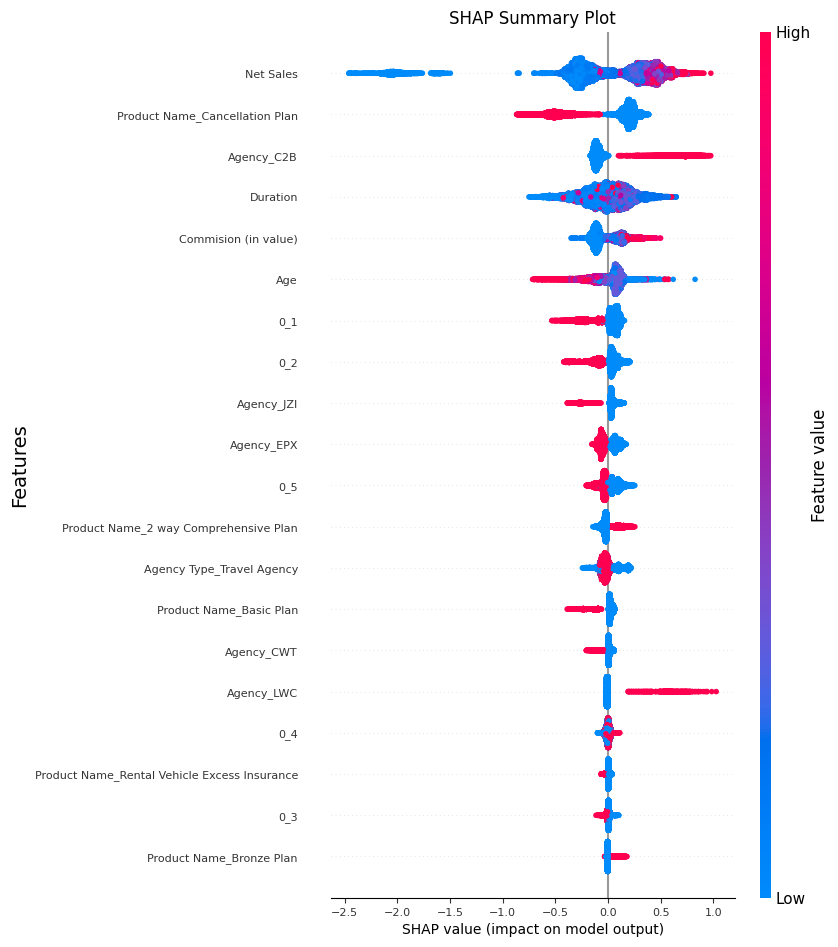

In [ ]:
plt.figure(figsize=(6,4))

shap.summary_plot(
    shap_values,
    x_train_df,
    show=False
)

# adjust font size
plt.gca().tick_params(labelsize=8)
plt.xlabel("SHAP value (impact on model output)", fontsize=10)
plt.ylabel("Features", fontsize=16)
plt.title("SHAP Summary Plot", fontsize=12)

# adjust margin 
plt.subplots_adjust(left=0.35)

plt.show()

The SHAP analysis reveals that both financial factors (Net Sales, Commission) and product-related features (certain Product Name and Agency) are strong drivers of claim risk.

These insights confirm that the model captures meaningful and interpretable patterns aligned with real-world business logic. The model does not rely on a single dominant feature but instead learns from a combination of financial, behavioral, and distribution-related variables, suggesting a well-balanced and robust decision-making process.

The model demonstrates:

- Strong performance in detecting claim cases (high recall)
- Balanced trade-off between recall and precision (validated by F2-score)
- Stable performance across training and test data (no significant overfitting)
- Transparent decision-making through SHAP analysis

Therefore, the model can be considered reliable and suitable for deployment, with the selected threshold ensuring alignment with business objectives.

# Section 10. Conclusion

Based on the end-to-end development of the machine learning model for travel insurance claim prediction, the following conclusions can be drawn:

1. Among all evaluated approaches (baseline, resampling, penalized, and hyperparameter tuning), the best-performing model is **LightGBM with hyperparameter tuning and imbalance handling using scale_pos_weight**, with an optimal decision threshold of **0.34**.

2. The model achieves the best balance between recall and precision, with key performance metrics:
   - Recall: ~0.80
   - Precision: ~0.047
   - F2-score: ~0.189
   - PR-AUC: ~0.093

   These results indicate that the model is able to detect the majority of claim cases while maintaining a manageable level of false positives, aligning with a balanced operational strategy.

3. Based on the refined cost-benefit analysis:
   - The model significantly reduces total risk-related cost compared to the baseline scenario (no model).
   - The reduction is primarily driven by a decrease in missed claims (False Negatives), which carry higher financial impact.
   - Although false positives increase, the associated cost is mainly opportunity cost and administrative effort, which is considered acceptable.

   Overall, the model achieves an estimated **cost reduction of 7.35%**, demonstrating its effectiveness in improving financial risk management and capital allocation.

# Section 11. Recommendation

## 11.1 Data Recommendations

- Add more specific features to our top drivers, such as 'product_price' and 'agency_claim_rate'
- Include **historical customer claim behavior**, as past behavior is often a strong predictor of future claims, for example 'past_claim_count' and 'avg_claim_amount'
- Add **temporal features** such as travel seasonality (peak vs off-peak periods), which may influence claim likelihood.
- Improve overall data quality by addressing missing values.

## 11.2 Model Recommendations

- Explore **threshold optimization based on business cost**, rather than relying solely on statistical metrics.
- Evaluate additional ensemble techniques such as **stacking or blending** to further improve performance.
- Extend explainability analysis using **SHAP dependence plots** to better understand feature interactions.
- Expand hyperparameter tuning with a larger search space or more iterations if computational resources allow.

## 11.3 Business Recommendations

- The model should be primarily used by the **Risk Management Team** to identify high-risk policyholders prior to or during policy issuance.

- Recommended usage:
  - During underwriting processes
  - Before pricing decisions
  - For flagging high-risk customers

- Deployment frequency:
  - Applied to every new policy (real-time or daily batch processing)

- Maintenance:
  - The model should be retrained every **3–6 months**, or when significant changes in claim patterns are observed.

- Business impact:
  - The model enables a **cost reduction of approximately 7.35%**, by improving risk detection and optimizing capital allocation.
  - This contributes to better financial stability and more informed decision-making across the organization.

# Section 12. Model Deployment

The final model is retrained using the full dataset to maximize learning from all available data. The trained model is then saved using joblib, allowing it to be deployed in production environments or integrated into business systems.

This ensures that the model is ready for real-world usage and can support decision-making processes effectively.

In [75]:
import joblib

# retrain final model with all data
best_model.fit(x, y)

# save model
joblib.dump(best_model, 'final_model.pkl')

[LightGBM] [Info] Number of positive: 666, number of negative: 37753
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001726 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 918
[LightGBM] [Info] Number of data points in the train set: 38419, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.017335 -> initscore=-4.037531
[LightGBM] [Info] Start training from score -4.037531
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

['final_model.pkl']

In [76]:
model = joblib.load('final_model.pkl')